In [10]:
import numpy as np
from scipy.integrate import fixed_quad, quad
from scipy.special import roots_legendre
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

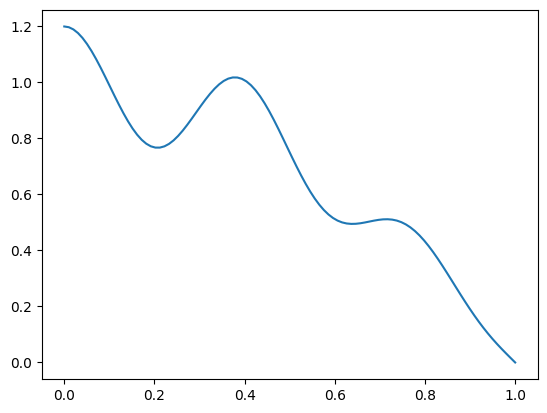

In [11]:
# test function for integration
f = lambda x: (1 + 0.2*np.cos(5*np.pi * x))*(1 - x**2)
x = np.linspace(0, 1, 100)
plt.plot(x, f(x))

## Manual computation of Gaussian quadrature

In [12]:
n = 3  # Order of quadrature (number of points)
x, w = roots_legendre(n)
print("Abscissas (x):", x)
print("Weights (w):", w)

# change of interval from [-1,1] to [0,1]
x = 0.5 * (x + 1)  # map from [-1,1] to [0,1]
w = 0.5 * w        # adjust weights accordingly

# integration: ∫[0,1] f(x) dx
quad_manual = np.sum(w * f(x))
quad_scipy, _ = fixed_quad(f, 0, 1, n = n)
print("Exact integral:", quad_scipy)  # Should be ~2/3
print("Approx integral:", quad_manual) # Should be ~2/3

Abscissas (x): [-0.77459667  0.          0.77459667]
Weights (w): [0.55555556 0.88888889 0.55555556]
Exact integral: 0.6581376592164981
Approx integral: 0.6581376592164981


In [31]:
# set a new range for integration
a, b = 0.8, 1.0

n = 5  # Order of quadrature (number of points)
x, w = roots_legendre(n)

# change of interval from [-1,1] to [0,1]
x = 0.5 * (x + 1)  # map from [-1,1] to [0,1]
w = 0.5 * w        # adjust weights accordingly

# option 1: Compute integral masking original quadrature points outside [a,b]
mask = (x >= a) & (x <= b)
quad_manual_masked = np.sum(w[mask] * f(x[mask]))

# option 2: Numerically integrate an interpolation function based on original quadrature points
cs = CubicSpline(x, f(x))
quad_manual_interp, _ = quad(cs, a, b)

# option 3: Generate exact integral with adaptive quadrature
quad_exact, _ = quad(f, a, b)

print(f"Approx integral (masked): {quad_manual_masked}")
print(f"Approx integral (interp): {quad_manual_interp}")
print(f"Exact integral: {quad_exact}")

Approx integral (masked): 0.009245983088142042
Approx integral (interp): 0.0405944431961399
Exact integral: 0.04025138342223264


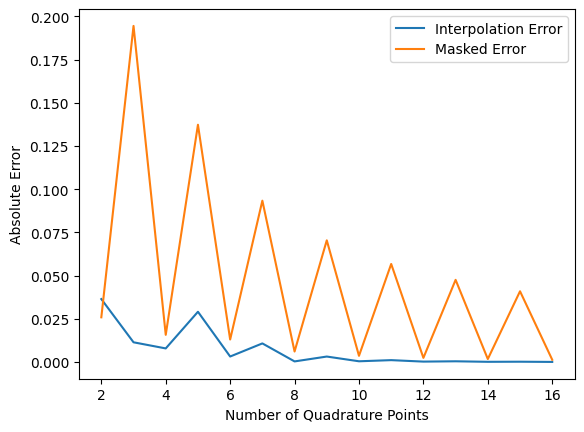

In [ ]:
# set a new range for integration
a, b = 0.5, 1.0
n_quad = np.arange(2, 17)

interp_errors = []
masked_errors = []
for n in n_quad:
    x, w = roots_legendre(n)

    # change of interval from [-1,1] to [0,1]
    x = 0.5 * (x + 1)  # map from [-1,1] to [0,1]
    w = 0.5 * w        # adjust weights accordingly

    # option 1: Compute integral masking original quadrature points outside [a,b]
    mask = (x >= a) & (x <= b)
    quad_manual_masked = np.sum(w[mask] * f(x[mask]))

    # option 2: Numerically integrate an interpolation function based on original quadrature points
    cs = CubicSpline(x, f(x))
    quad_manual_interp, _ = quad(cs, a, b)

    # Generate exact integral with adaptive quadrature
    quad_exact, _ = quad(f, a, b)

    # compute errors
    interp_errors.append(abs(quad_manual_interp - quad_exact))
    masked_errors.append(abs(quad_manual_masked - quad_exact))

plt.plot(n_quad, interp_errors, 'o k',label='Interpolation Error')
plt.plot(n_quad, masked_errors, 's r', label='Masked Error')
plt.xlabel('Number of Quadrature Points')
plt.ylabel('Absolute Error')
plt.legend()
plt.show()

In [24]:
w[mask]

array([0.44444444, 0.27777778])